In [9]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq


load_dotenv()

model = ChatGroq(
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model="llama-3.1-8b-instant",  # free + fast
    temperature=0.0
)

response = model.invoke("Exploan low latency games ? in 2 lines maximum")
print(response.content)


Low-latency games include: 

1. First-person shooters (FPS) like Call of Duty and Overwatch.
2. Fighting games like Street Fighter and Mortal Kombat.


## **First Graph**

#### **Step 1 - Define The Schema**

In [10]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    name : str
    message : str

#### Step 2 - Create a Node Functions

In [11]:
def welcome(state : graph_schema) -> graph_schema:
    currentName = state['name']
    currentMessage = state['message']

    response = model.invoke(f"my name is {currentName}. {currentMessage}").content

    # convert the our message to ai message
    state['message'] = f"your message was {currentMessage}. here response is : "  + response

    return state


#### **Step 3 - Create a State Graph**

In [12]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)
# Adding a node
graph.add_node("welcome", welcome)

#  Adding a edges
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)

#### **Step 4 - Compline the graph**

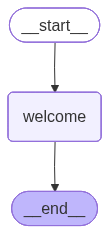

In [13]:
from IPython.display import Image, display

firstGraph = graph.compile()

#  display the graph
Image(firstGraph.get_graph().draw_mermaid_png())

#### **Step 5 - Run the Graph**

In [14]:
# it should follow the schema
firstGraph.invoke({"name" : "dhanushkumar", "message" : "How are you?"})

{'name': 'dhanushkumar',
 'message': "your message was How are you?. here response is : Nice to meet you, Dhanushkumar. I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or topics you'd like to discuss. How about you? How's your day going so far?"}